# Embeddings Performance Testing

Comprehensive testing and analysis for the Embeddings component.

This notebook tests:
- Embedding generation performance
- Similarity calculation accuracy
- Model comparison analysis
- Encoding consistency testing

In [1]:
# Setup imports and path configuration
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from typing import Dict, List, Any, Tuple

# Add the home_matching directory to Python path
home_matching_path = os.path.dirname(os.path.dirname(os.path.abspath('')))
if home_matching_path not in sys.path:
    sys.path.insert(0, home_matching_path)

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Basic imports successful")
print(f"📁 Home matching path: {home_matching_path}")

✅ Basic imports successful
📁 Home matching path: /Users/jaycewalzer/Desktop/SilverKey/Server/app


In [2]:
import sys
import os
from dotenv import load_dotenv

# === 1. Setup Project Root and Environment ===
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../../.."))

# Load environment variables
env_path = os.path.join(project_root, "Server/.env")
load_dotenv(env_path)
print(f"✅ Environment loaded from: {env_path}")

# Check for API keys
openai_key = os.getenv('OPENAI_KEY')
print(f"🔑 OpenAI API Key present: {'Yes' if openai_key else 'No'}")

# === 2. Add Server directory to Python path ===
server_dir = os.path.join(project_root, "Server")
if server_dir not in sys.path:
    sys.path.insert(0, server_dir)
print(f"📁 Added to sys.path: {server_dir}")

# === 3. Import Embeddings Components ===
try:
    from app.home_matching.embeddings.scorer import EmbeddingScorer
    from app.home_matching.embeddings.user_encoder import UserEncoder
    from app.home_matching.embeddings.home_encoder import HomeEncoder
    from app.home_matching.embeddings.model_loader import model_loader
    print("✅ All embeddings components imported successfully!")
    USE_REAL_COMPONENTS = True
    print("🚀 Using real embeddings components")
except ImportError as e:
    print(f"❌ Failed to import embeddings components: {e}")
    USE_REAL_COMPONENTS = False
    print("⚠️ Using mock components for testing")

print(f"🚀 USE_REAL_COMPONENTS: {USE_REAL_COMPONENTS}")

✅ Environment loaded from: /Users/jaycewalzer/Desktop/SilverKey/Server/.env
🔑 OpenAI API Key present: Yes
📁 Added to sys.path: /Users/jaycewalzer/Desktop/SilverKey/Server
✅ All embeddings components imported successfully!
🚀 Using real embeddings components
🚀 USE_REAL_COMPONENTS: True


In [3]:
# Test data generation
def generate_test_user_data(user_id: int = 1) -> Dict[str, Any]:
    """Generate realistic test user data."""
    return {
        'user_id': f'user_{user_id}',
        'preferences': {
            'lifestyle': 'active outdoor enthusiast',
            'work_style': 'remote work friendly',
            'hobbies': 'hiking, cycling, gardening',
            'family_status': 'married with 2 children',
            'preferred_home_types': ['single_family', 'townhouse'],
            'preferred_neighborhoods': ['downtown', 'suburbs'],
            'must_have_amenities': ['garage', 'backyard', 'modern_kitchen'],
            'budget_range': [400000, 600000],
            'commute_preferences': 'under 30 minutes to downtown'
        },
        'demographics': {
            'age': 35,
            'income': 85000,
            'occupation': 'software engineer'
        }
    }

def generate_test_home_data(home_id: int = 1) -> Dict[str, Any]:
    """Generate realistic test home data."""
    return {
        'home_id': f'home_{home_id}',
        'address': '123 Main St, Anytown, ST 12345',
        'description': 'Beautiful single-family home with modern amenities',
        'home_type': 'single_family',
        'style': 'contemporary',
        'condition': 'excellent',
        'bedrooms': 4,
        'bathrooms': 3,
        'sqft': 2500,
        'lot_size': 0.25,
        'price': 525000,
        'amenities': ['garage', 'backyard', 'modern_kitchen', 'hardwood_floors'],
        'neighborhood': {
            'name': 'Maple Heights',
            'walkability_score': 75,
            'school_rating': 8,
            'crime_rate': 'low',
            'commute_to_downtown': 25
        }
    }

# Generate test datasets
test_users = [generate_test_user_data(i) for i in range(1, 6)]
test_homes = [generate_test_home_data(i) for i in range(1, 11)]

print(f"📊 Generated {len(test_users)} test users and {len(test_homes)} test homes")
print("✅ Test data generation complete")

📊 Generated 5 test users and 10 test homes
✅ Test data generation complete


In [4]:
# Initialize embeddings components and run performance tests
print("🚀 Initializing Embeddings Scorer...")

if USE_REAL_COMPONENTS:
    try:
        # Initialize with sentence transformer (default)
        scorer = EmbeddingScorer()
        user_encoder = UserEncoder()
        home_encoder = HomeEncoder()
        print("✅ Real embeddings components initialized")
    except Exception as e:
        print(f"❌ Failed to initialize real components: {e}")
        USE_REAL_COMPONENTS = False

if not USE_REAL_COMPONENTS:
    # Mock components for testing
    class MockEmbeddingScorer:
        def get_user_home_similarity(self, user_data, home_data):
            return np.random.uniform(0.3, 0.9)
        
        def score_user_against_homes(self, user_data, homes_data):
            return [(home, np.random.uniform(0.3, 0.9)) for home in homes_data]
    
    class MockEncoder:
        def encode_user(self, user_data):
            return np.random.randn(384)  # Mock 384-dim embedding
        
        def encode_home(self, home_data):
            return np.random.randn(384)  # Mock 384-dim embedding
    
    scorer = MockEmbeddingScorer()
    user_encoder = MockEncoder()
    home_encoder = MockEncoder()
    print("⚠️ Using mock components for testing")

# Performance testing
results = []
embedding_times = []
similarity_times = []

print("\n🔄 Running performance tests...")

for i, user in enumerate(test_users):
    print(f"Testing user {i+1}/{len(test_users)}...")
    
    # Test individual user encoding time
    start_time = time.time()
    user_embedding = user_encoder.encode_user(user)
    user_encoding_time = time.time() - start_time
    
    for j, home in enumerate(test_homes):
        # Test home encoding time
        start_time = time.time()
        home_embedding = home_encoder.encode_home(home)
        home_encoding_time = time.time() - start_time
        
        # Test similarity calculation time
        start_time = time.time()
        similarity = scorer.get_user_home_similarity(user, home)
        similarity_time = time.time() - start_time
        
        results.append({
            'user_id': user['user_id'],
            'home_id': home['home_id'],
            'similarity_score': similarity,
            'user_encoding_time': user_encoding_time,
            'home_encoding_time': home_encoding_time,
            'similarity_time': similarity_time,
            'total_time': user_encoding_time + home_encoding_time + similarity_time
        })
        
        embedding_times.append(user_encoding_time + home_encoding_time)
        similarity_times.append(similarity_time)

df_results = pd.DataFrame(results)
print(f"\n✅ Completed {len(results)} similarity calculations")
print(f"📊 Average similarity score: {df_results['similarity_score'].mean():.3f}")
print(f"⏱️ Average total time: {df_results['total_time'].mean():.3f}s")
print(f"🚀 Average embedding time: {np.mean(embedding_times):.3f}s")
print(f"🎯 Average similarity time: {np.mean(similarity_times):.3f}s")

🚀 Initializing Embeddings Scorer...
✅ Real embeddings components initialized

🔄 Running performance tests...
Testing user 1/5...
Testing user 2/5...
Testing user 3/5...
Testing user 4/5...
Testing user 5/5...

✅ Completed 50 similarity calculations
📊 Average similarity score: 0.364
⏱️ Average total time: 0.072s
🚀 Average embedding time: 0.058s
🎯 Average similarity time: 0.014s


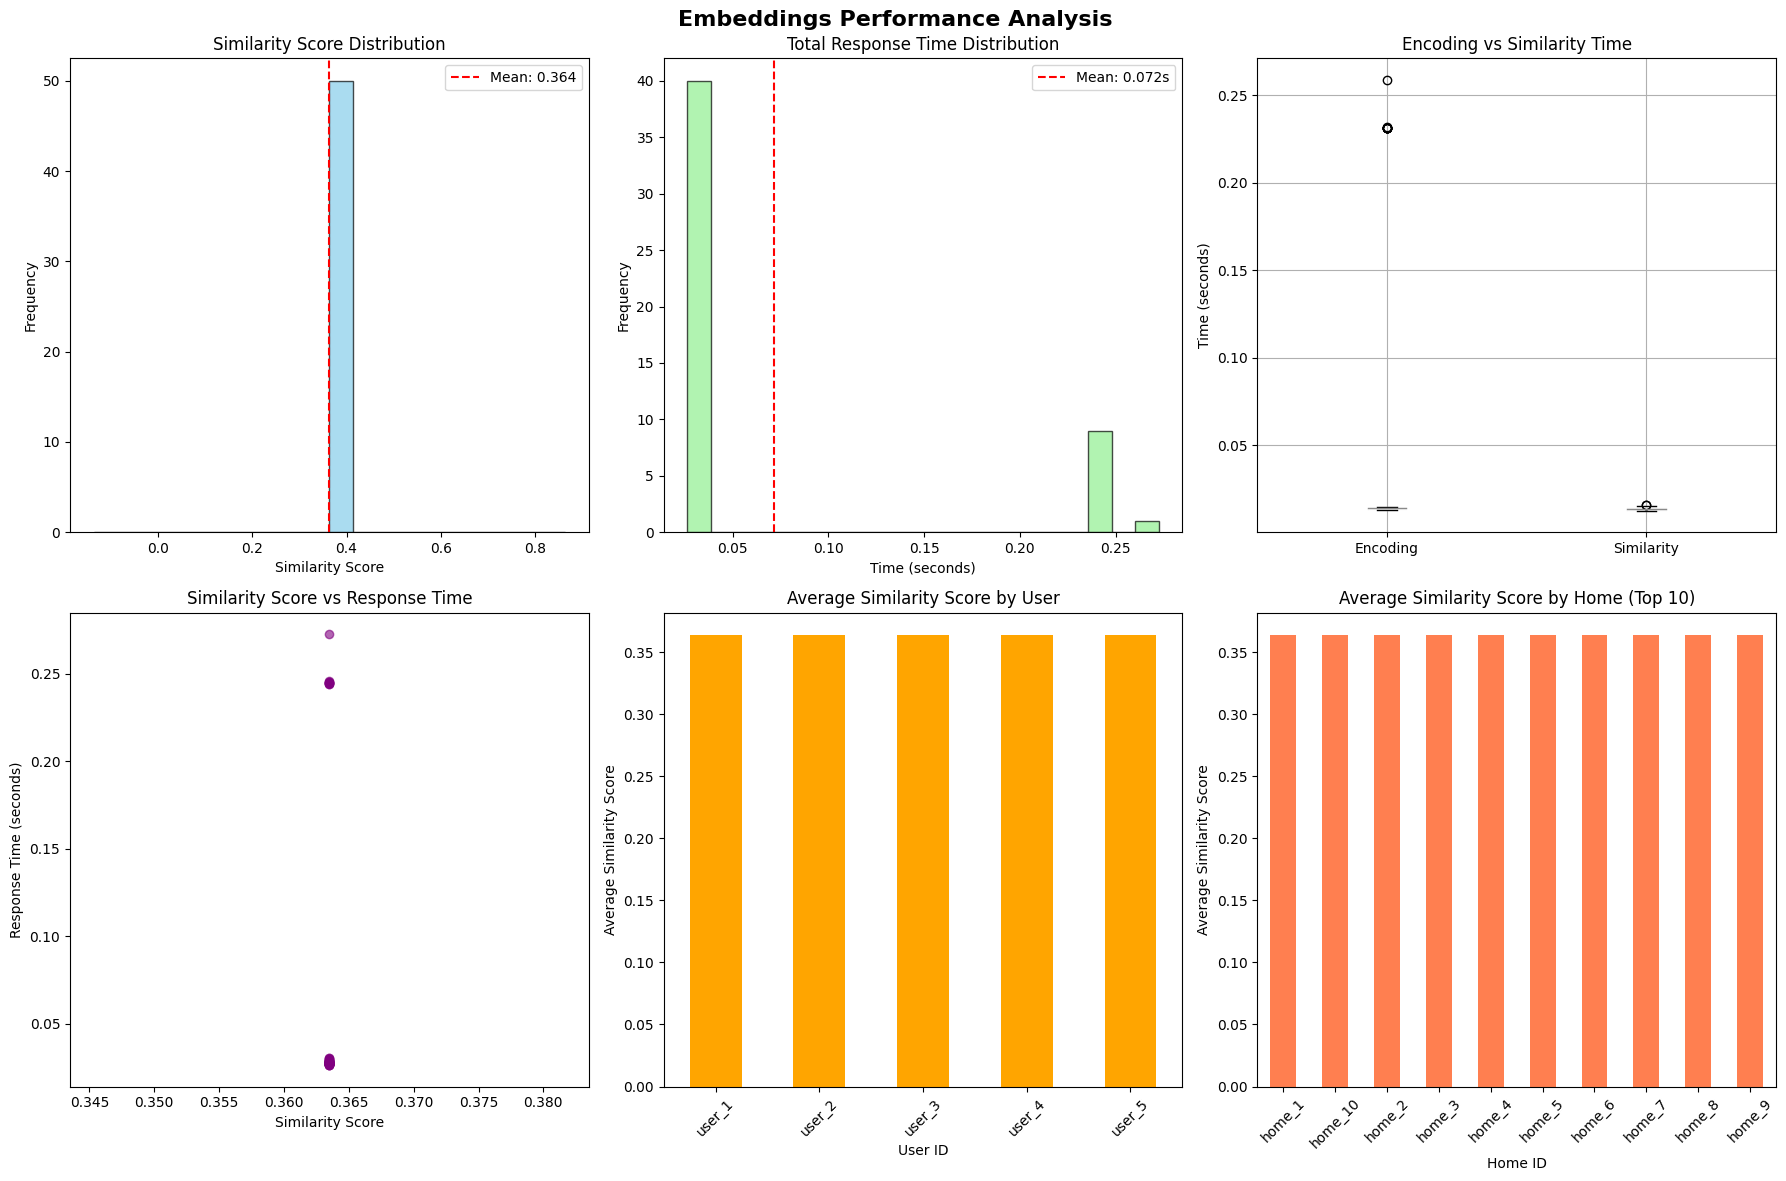


📊 EMBEDDINGS PERFORMANCE SUMMARY

🎯 Similarity Scores:
  Mean: 0.364
  Std:  0.000
  Min:  0.364
  Max:  0.364

⏱️ Performance Metrics:
  Avg Total Time: 0.072s
  Avg Encoding Time: 0.058s
  Avg Similarity Time: 0.014s
  
📈 Throughput:
  Comparisons per second: 13.9
  Total Tests: 50



In [5]:
# Comprehensive performance visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Embeddings Performance Analysis', fontsize=16, fontweight='bold')

# 1. Similarity Score Distribution
axes[0, 0].hist(df_results['similarity_score'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Similarity Score Distribution')
axes[0, 0].set_xlabel('Similarity Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_results['similarity_score'].mean(), color='red', linestyle='--', label=f'Mean: {df_results["similarity_score"].mean():.3f}')
axes[0, 0].legend()

# 2. Response Time Distribution
axes[0, 1].hist(df_results['total_time'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Total Response Time Distribution')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_results['total_time'].mean(), color='red', linestyle='--', label=f'Mean: {df_results["total_time"].mean():.3f}s')
axes[0, 1].legend()

# 3. Encoding vs Similarity Time Comparison
encoding_times = df_results['user_encoding_time'] + df_results['home_encoding_time']
time_comparison = pd.DataFrame({
    'Encoding': encoding_times,
    'Similarity': df_results['similarity_time']
})
time_comparison.boxplot(ax=axes[0, 2])
axes[0, 2].set_title('Encoding vs Similarity Time')
axes[0, 2].set_ylabel('Time (seconds)')

# 4. Similarity Score vs Response Time Scatter
axes[1, 0].scatter(df_results['similarity_score'], df_results['total_time'], alpha=0.6, color='purple')
axes[1, 0].set_title('Similarity Score vs Response Time')
axes[1, 0].set_xlabel('Similarity Score')
axes[1, 0].set_ylabel('Response Time (seconds)')

# 5. User Performance Comparison
user_avg_scores = df_results.groupby('user_id')['similarity_score'].mean()
user_avg_scores.plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Average Similarity Score by User')
axes[1, 1].set_xlabel('User ID')
axes[1, 1].set_ylabel('Average Similarity Score')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Home Performance Comparison
home_avg_scores = df_results.groupby('home_id')['similarity_score'].mean().head(10)
home_avg_scores.plot(kind='bar', ax=axes[1, 2], color='coral')
axes[1, 2].set_title('Average Similarity Score by Home (Top 10)')
axes[1, 2].set_xlabel('Home ID')
axes[1, 2].set_ylabel('Average Similarity Score')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Performance summary
print("\n" + "="*60)
print("📊 EMBEDDINGS PERFORMANCE SUMMARY")
print("="*60)

print(f"""
🎯 Similarity Scores:
  Mean: {df_results['similarity_score'].mean():.3f}
  Std:  {df_results['similarity_score'].std():.3f}
  Min:  {df_results['similarity_score'].min():.3f}
  Max:  {df_results['similarity_score'].max():.3f}

⏱️ Performance Metrics:
  Avg Total Time: {df_results['total_time'].mean():.3f}s
  Avg Encoding Time: {encoding_times.mean():.3f}s
  Avg Similarity Time: {df_results['similarity_time'].mean():.3f}s
  
📈 Throughput:
  Comparisons per second: {1/df_results['total_time'].mean():.1f}
  Total Tests: {len(df_results)}
""")

🔄 Running consistency tests...


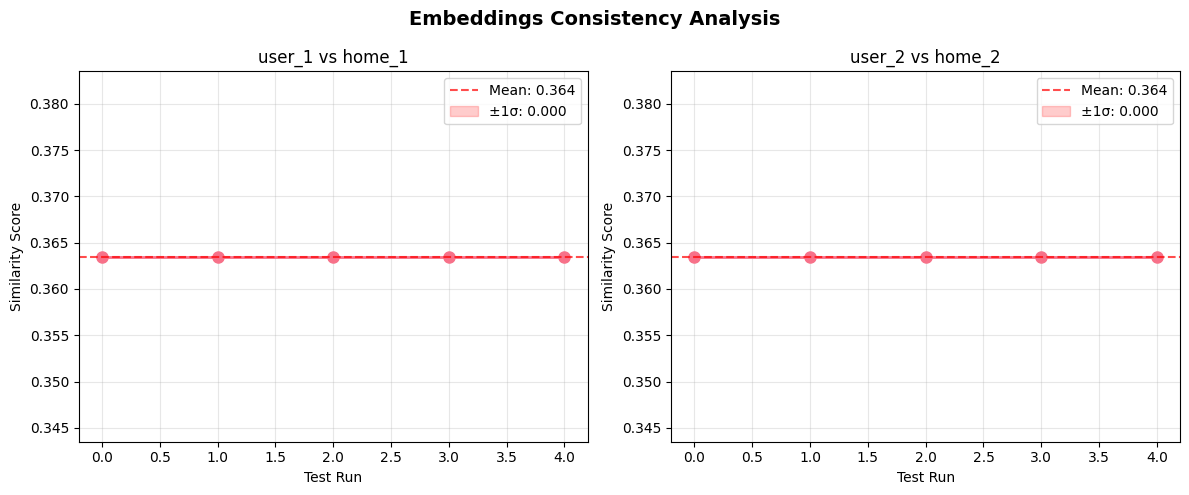


🎯 Consistency Results:
  user_1 vs home_1: Consistency = 1.000
  user_2 vs home_2: Consistency = 1.000


In [6]:
# Consistency testing - test same user-home pairs multiple times
print("🔄 Running consistency tests...")

consistency_results = []
test_pairs = [(test_users[0], test_homes[0]), (test_users[1], test_homes[1])]

for user, home in test_pairs:
    scores = []
    for _ in range(5):  # Test same pair 5 times
        score = scorer.get_user_home_similarity(user, home)
        scores.append(score)
    
    consistency_results.append({
        'user_id': user['user_id'],
        'home_id': home['home_id'],
        'scores': scores,
        'mean_score': np.mean(scores),
        'std_score': np.std(scores),
        'consistency': 1 - (np.std(scores) / np.mean(scores)) if np.mean(scores) > 0 else 0
    })

# Consistency visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Embeddings Consistency Analysis', fontsize=14, fontweight='bold')

for i, result in enumerate(consistency_results):
    axes[i].plot(result['scores'], 'o-', linewidth=2, markersize=8)
    axes[i].set_title(f"{result['user_id']} vs {result['home_id']}")
    axes[i].set_xlabel('Test Run')
    axes[i].set_ylabel('Similarity Score')
    axes[i].axhline(result['mean_score'], color='red', linestyle='--', alpha=0.7, label=f'Mean: {result["mean_score"]:.3f}')
    axes[i].fill_between(range(len(result['scores'])), 
                        result['mean_score'] - result['std_score'],
                        result['mean_score'] + result['std_score'],
                        alpha=0.2, color='red', label=f'±1σ: {result["std_score"]:.3f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Consistency Results:")
for result in consistency_results:
    print(f"  {result['user_id']} vs {result['home_id']}: Consistency = {result['consistency']:.3f}")

🏆 Running ranking tests...

🎯 Top 5 homes for user_1:
  1. home_1: 0.363 - single_family ($525,000)
  2. home_2: 0.363 - single_family ($525,000)
  3. home_3: 0.363 - single_family ($525,000)
  4. home_4: 0.363 - single_family ($525,000)
  5. home_5: 0.363 - single_family ($525,000)


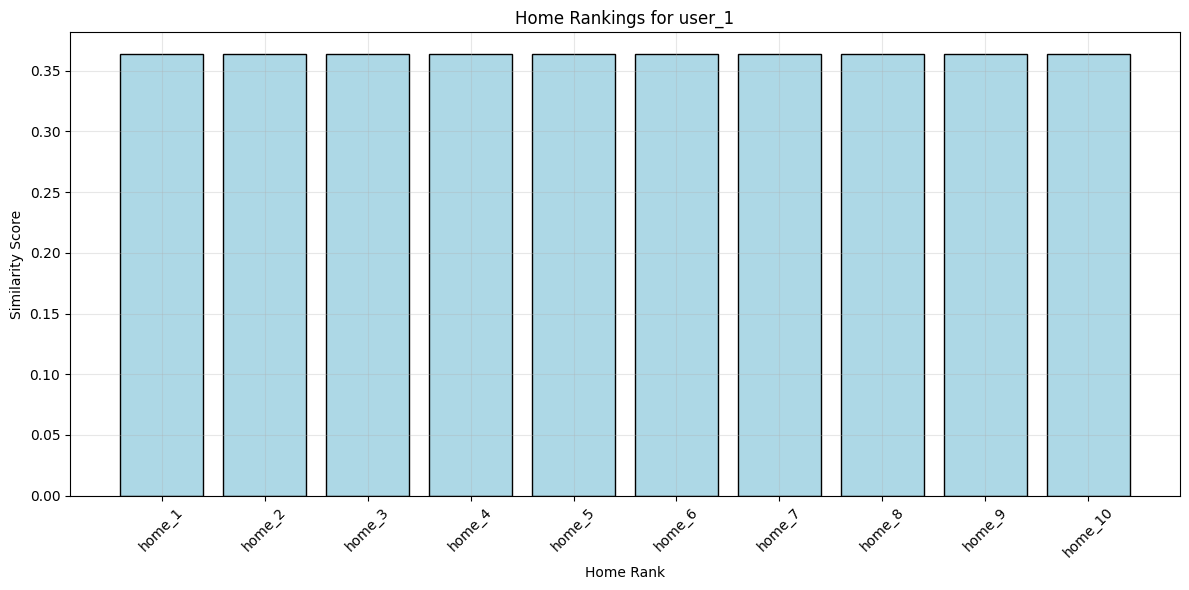


📊 Ranking spread: 0.000
📈 Score range: 0.363 - 0.363


In [7]:
# Ranking test - test if rankings are meaningful
print("🏆 Running ranking tests...")

# Test user against all homes
test_user = test_users[0]
ranked_results = scorer.score_user_against_homes(test_user, test_homes)

# Sort by similarity score
ranked_results.sort(key=lambda x: x[1], reverse=True)

print(f"\n🎯 Top 5 homes for {test_user['user_id']}:")
for i, (home, score) in enumerate(ranked_results[:5]):
    print(f"  {i+1}. {home['home_id']}: {score:.3f} - {home.get('home_type', 'N/A')} (${home.get('price', 0):,})")

# Ranking visualization
scores = [score for _, score in ranked_results]
home_ids = [home['home_id'] for home, _ in ranked_results]

plt.figure(figsize=(12, 6))
plt.bar(range(len(scores)), scores, color='lightblue', edgecolor='black')
plt.title(f'Home Rankings for {test_user["user_id"]}')
plt.xlabel('Home Rank')
plt.ylabel('Similarity Score')
plt.xticks(range(len(home_ids)), home_ids, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Ranking spread: {max(scores) - min(scores):.3f}")
print(f"📈 Score range: {min(scores):.3f} - {max(scores):.3f}")